# **Telecom X - Análisis de Evasión de Clientes**

# **Churn de Clientes**

La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

## **Extracción**

### **1. Extracción de datos**

Para iniciar tu análisis, necesitarás importar los datos de la API de Telecom X. Estos datos están disponibles en formato JSON y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

📌 Enlace de la API:
🔗 challenge2-data-science-LATAM/TelecomX_Data.json at main · ingridcristh/challenge2-data-science-LATAM

🔗GitHub - ingridcristh/challenge2-data-science-LATAM

In [109]:
import pandas as pd

In [110]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

df_raw = pd.read_json(url)

df_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [111]:
print("Dimensiones (raw):", df_raw.shape)
display(df_raw.head())

Dimensiones (raw): (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [112]:
display(df_raw.info())
display(df_raw.iloc[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


None

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


## **Transformación**

### **2. Conoce el conjunto de datos**
Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

📌 Para facilitar este proceso, hemos creado un diccionario de datos con la descripción de cada columna. Aunque no es obligatorio utilizarlo, puede ayudarte a comprender mejor la información disponible.

🔗 Enlace al diccionario y a la API

¿Qué debes hacer?
✅ Explorar las columnas del dataset y verificar sus tipos de datos.
✅ Consultar el diccionario para comprender mejor el significado de las variables.
✅ Identificar las columnas más relevantes para el análisis de evasión.

Revisar tipos de columnas

In [113]:
print("Columnas (raw):", df_raw.columns.tolist())
display(df_raw.dtypes)

Columnas (raw): ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']


,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


nulos

In [114]:
nulos_raw = df_raw.isna().sum().sort_values(ascending=False)
print("\nNulos por columna (raw) — top 15:")
display(nulos_raw.head(15))


Nulos por columna (raw) — top 15:


,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


duplicados

In [115]:
print("Duplicados customerID (raw):", df_raw["customerID"].duplicated().sum())

Duplicados customerID (raw): 0


Detectar variables

In [116]:
registro = df_raw.iloc[0]
print("\nVariables anidadas detectadas:")
for col in df_raw.columns:
    if isinstance(registro[col], dict):
        print(f" - {col}: {list(registro[col].keys())}")


Variables anidadas detectadas:
 - customer: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']
 - phone: ['PhoneService', 'MultipleLines']
 - internet: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
 - account: ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges']


### **3. Comprobación de incoherencias en los datos**

En este paso, verifica si hay problemas en los datos que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.

Aplanar

In [117]:
import numpy as np

In [118]:
df_plano = pd.json_normalize(df_raw.to_dict(orient="records"))

print("Dimensiones (plano):", df_plano.shape)
display(df_plano.head())

Dimensiones (plano): (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Limpieza base

In [119]:
columnas_obj = df_plano.select_dtypes(include="object").columns
df_plano[columnas_obj] = df_plano[columnas_obj].apply(lambda s: s.astype(str).str.strip())
df_plano[columnas_obj] = df_plano[columnas_obj].replace({"": np.nan, "nan": np.nan, "None": np.nan})


Filtrar registro sin churn

In [120]:
df_limpio = df_plano[df_plano["Churn"].notna()].copy()
print("Dimensiones (sin churn nulo):", df_limpio.shape)

Dimensiones (sin churn nulo): (7043, 21)


Convertir variables

In [121]:
for col in ["account.Charges.Total", "account.Charges.Monthly", "customer.tenure", "customer.SeniorCitizen"]:
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

In [122]:
if "customer.tenure" in df_limpio.columns and "account.Charges.Total" in df_limpio.columns:
    mask = (df_limpio["customer.tenure"] == 0) & (df_limpio["account.Charges.Total"].isna())
    df_limpio.loc[mask, "account.Charges.Total"] = 0

In [123]:
print("\nNulos principales (post C) — top 15:")
display(df_limpio.isna().sum().sort_values(ascending=False).head(15))


Nulos principales (post C) — top 15:


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


### **4. Manejo de inconsistencias**

Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

In [124]:
print("Dimensiones actuales:", df_limpio.shape)

print("\nNulos principales — top 15:")
display(df_limpio.isna().sum().sort_values(ascending=False).head(15))

# Chequeos rápidos de coherencia numérica (aún con nombres originales del JSON)
checks_raw = {}
if "account.Charges.Total" in df_limpio.columns:
    checks_raw["Charges.Total_nulos"] = int(df_limpio["account.Charges.Total"].isna().sum())
if "account.Charges.Monthly" in df_limpio.columns:
    checks_raw["Charges.Monthly_nulos"] = int(df_limpio["account.Charges.Monthly"].isna().sum())
if "customer.tenure" in df_limpio.columns:
    checks_raw["tenure_nulos"] = int(df_limpio["customer.tenure"].isna().sum())

print("Chequeos rápidos:", checks_raw)

display(df_limpio.head())

Dimensiones actuales: (7043, 21)

Nulos principales — top 15:


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


Chequeos rápidos: {'Charges.Total_nulos': 0, 'Charges.Monthly_nulos': 0, 'tenure_nulos': 0}


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


### **5. Columna de cuentas diarias**

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

Columna cuentas diarias

In [125]:
df_limpio["cuentas_diarias"] = df_limpio["account.Charges.Monthly"] / 30

In [126]:
display(df_limpio[["account.Charges.Monthly", "cuentas_diarias"]].head())
display(df_limpio["cuentas_diarias"].describe())
print("Valores negativos en cuentas_diarias:", (df_limpio["cuentas_diarias"] < 0).sum())

,account.Charges.Monthly,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


,cuentas_diarias
count,7043.000000
mean,2.158723
std,1.003002
min,0.608333
25%,1.183333
50%,2.345000
75%,2.995000
max,3.958333


Valores negativos en cuentas_diarias: 0


### **6. Estandarización y transformación de datos**

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

Renombrar columnas a español

In [127]:
renombrar_es = {
    "customer.gender": "género",
    "customer.SeniorCitizen": "adulto_mayor",
    "customer.Partner": "tiene_pareja",
    "customer.Dependents": "tiene_dependientes",
    "customer.tenure": "antigüedad_meses",

    "phone.PhoneService": "servicio_telefonía",
    "phone.MultipleLines": "múltiples_líneas",

    "internet.InternetService": "servicio_internet",
    "internet.OnlineSecurity": "seguridad_online",
    "internet.OnlineBackup": "respaldo_online",
    "internet.DeviceProtection": "protección_dispositivo",
    "internet.TechSupport": "soporte_técnico",
    "internet.StreamingTV": "streaming_tv",
    "internet.StreamingMovies": "streaming_películas",

    "account.Contract": "tipo_contrato",
    "account.PaperlessBilling": "facturación_sin_papel",
    "account.PaymentMethod": "método_pago",
    "account.Charges.Monthly": "cargo_mensual",
    "account.Charges.Total": "cargo_total",
}
df_limpio.rename(columns={k: v for k, v in renombrar_es.items() if k in df_limpio.columns}, inplace=True)

Simplificar categorias

In [128]:
columnas_internet = [
    "seguridad_online",
    "respaldo_online",
    "protección_dispositivo",
    "soporte_técnico",
    "streaming_tv",
    "streaming_películas",
]
for col in columnas_internet:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].replace({"No internet service": "No"})

if "múltiples_líneas" in df_limpio.columns:
    df_limpio["múltiples_líneas"] = df_limpio["múltiples_líneas"].replace({"No phone service": "No"})

Traducir categorías


In [129]:
if "servicio_internet" in df_limpio.columns:
    df_limpio["servicio_internet"] = df_limpio["servicio_internet"].replace({
        "Fiber optic": "Fibra óptica",
        "DSL": "DSL",
        "No": "Sin servicio",
    })

if "tipo_contrato" in df_limpio.columns:
    df_limpio["tipo_contrato"] = df_limpio["tipo_contrato"].replace({
        "Month-to-month": "Mensual",
        "One year": "Anual",
        "Two year": "Bianual",
    })

if "método_pago" in df_limpio.columns:
    df_limpio["método_pago"] = df_limpio["método_pago"].replace({
        "Electronic check": "Cheque electrónico",
        "Mailed check": "Cheque enviado",
        "Bank transfer (automatic)": "Transferencia automática",
        "Credit card (automatic)": "Tarjeta automática",
    })


Churn binario

In [130]:
df_limpio["churn_bin"] = df_limpio["Churn"].map({"Yes": 1, "No": 0})

In [131]:
columnas_obj = df_limpio.select_dtypes(include="object").columns
excluir = {"customerID", "Churn", "género", "tipo_contrato", "método_pago", "servicio_internet"}

columnas_binarias = [
    col for col in columnas_obj
    if col not in excluir and set(df_limpio[col].dropna().unique()).issubset({"Yes", "No"})
]

for col in columnas_binarias:
    df_limpio[col] = df_limpio[col].map({"Yes": 1, "No": 0})

todo bien con el churn?

In [132]:
df_limpio["churn_bin"] = df_limpio["Churn"].map({"Yes": 1, "No": 0})

Asegurar columnas numéricas

In [133]:
for col in ["antigüedad_meses", "cargo_mensual", "cargo_total", "cuentas_diarias", "adulto_mayor"]:
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")


Chequeo

In [134]:
checks = {}
if "cargo_total" in df_limpio.columns:
    checks["cargo_total_negativo"] = int((df_limpio["cargo_total"] < 0).sum())
if "cargo_mensual" in df_limpio.columns:
    checks["cargo_mensual_negativo"] = int((df_limpio["cargo_mensual"] < 0).sum())
if "antigüedad_meses" in df_limpio.columns:
    checks["antigüedad_negativa"] = int((df_limpio["antigüedad_meses"] < 0).sum())
if "cuentas_diarias" in df_limpio.columns:
    checks["cuentas_diarias_negativas"] = int((df_limpio["cuentas_diarias"] < 0).sum())

print("Chequeos de incoherencias:", checks)

# 6.5 (Opcional pero útil) Etiqueta de churn para gráficos (evita 0/1)
df_limpio["churn_label"] = df_limpio["Churn"].map({
    "Yes": "Evade (churn=Yes)",
    "No": "No evade (churn=No)"
})

Chequeos de incoherencias: {'cargo_total_negativo': 0, 'cargo_mensual_negativo': 0, 'antigüedad_negativa': 0, 'cuentas_diarias_negativas': 0}


## **Carga y Análisis**

### **7. Análisis Descriptivo**

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

Resumen estadistico general

In [135]:
cols_num = df_limpio.select_dtypes(include="number").columns.tolist()

resumen = df_limpio[cols_num].describe().T
resumen["mediana"] = df_limpio[cols_num].median(numeric_only=True)
resumen["varianza"] = df_limpio[cols_num].var(numeric_only=True)
resumen = resumen.sort_index()

display(resumen)

,count,mean,std,min,25%,50%,75%,max,mediana,varianza
adulto_mayor,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000,1.000000,0.000,1.358745e-01
antigüedad_meses,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000,29.000,6.031681e+02
cargo_mensual,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000,70.350,9.054109e+02
cargo_total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000,1394.550,5.138357e+06
churn_bin,7043.0,0.265370,0.441561,0.000000,0.000000,0.000,1.000,1.000000,0.000,1.949764e-01
cuentas_diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333,2.345,1.006012e+00
facturación_sin_papel,7043.0,0.592219,0.491457,0.000000,0.000000,1.000,1.000,1.000000,1.000,2.415299e-01
múltiples_líneas,7043.0,0.421837,0.493888,0.000000,0.000000,0.000,1.000,1.000000,0.000,2.439252e-01
protección_dispositivo,7043.0,0.343888,0.475038,0.000000,0.000000,0.000,1.000,1.000000,0.000,2.256609e-01
respaldo_online,7043.0,0.344881,0.475363,0.000000,0.000000,0.000,1.000,1.000000,0.000,2.259703e-01


Media, mediana y desviación estándar

In [136]:
vars_num_interes = [c for c in ["antigüedad_meses", "cargo_mensual", "cargo_total", "cuentas_diarias"] if c in df_limpio.columns]

comparacion = (
    df_limpio
    .groupby("Churn")[vars_num_interes]
    .agg(["mean", "median", "std"])
)

display(comparacion)

antigüedad_meses                   cargo_mensual                     \
                  mean median        std          mean  median        std   
Churn                                                                       
No           37.569965   38.0  24.113777     61.265124  64.425  31.092648   
Yes          17.979133   10.0  19.531123     74.441332  79.650  24.666053   

       cargo_total                        cuentas_diarias                    
              mean    median          std            mean  median       std  
Churn                                                                        
No     2549.911442  1679.525  2329.954215        2.042171  2.1475  1.036422  
Yes    1531.796094   703.550  1890.822994        2.481378  2.6550  0.822202

### **8. Distribución de evasión**

En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

Definir colores a trabajar

In [137]:
color_fiel = "#20B2AA"
color_evasion = "#7B2CBF"

Conteo y porcentaje

In [138]:
distribucion = df_limpio["Churn"].value_counts()
distribucion_pct = df_limpio["Churn"].value_counts(normalize=True) * 100

print("Conteo churn:")
display(distribucion)

print("Porcentaje churn:")
display(distribucion_pct)

Conteo churn:


,count
Churn,
No,5174
Yes,1869


Porcentaje churn:


,proportion
Churn,
No,73.463013
Yes,26.536987


Grafico de barras

In [139]:
import matplotlib.pyplot as plt

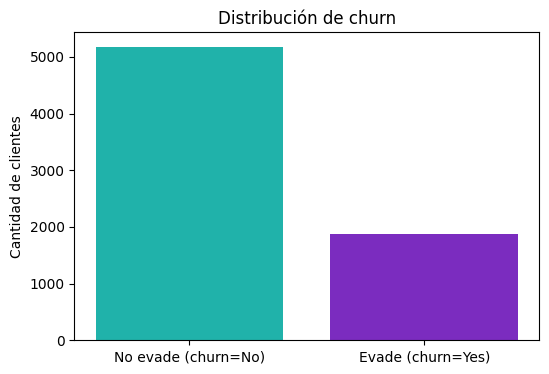

In [140]:
plt.figure(figsize=(6,4))

valores = [
    distribucion.get("No", 0),
    distribucion.get("Yes", 0)
]

plt.bar(
    ["No evade (churn=No)", "Evade (churn=Yes)"],
    valores,
    color=[color_fiel, color_evasion]
)

plt.title("Distribución de churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

Grafico de torta

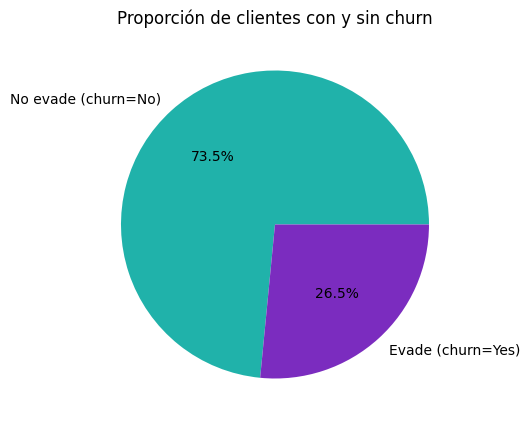

In [141]:
plt.figure(figsize=(6,5))

plt.pie(
    [distribucion.get("No", 0), distribucion.get("Yes", 0)],
    labels=["No evade (churn=No)", "Evade (churn=Yes)"],
    autopct="%1.1f%%",
    colors=[color_fiel, color_evasion]
)

plt.title("Proporción de clientes con y sin churn")
plt.show()

### **9. Recuento de evasión por variables categóricas**

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

Tabla conteo y tabla %

In [142]:
def churn_por_categoria(df, columna):
    tabla_pct = (
        df.groupby(columna)["Churn"]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0) * 100
    )
    tabla_cnt = (
        df.groupby(columna)["Churn"]
        .value_counts()
        .unstack()
        .fillna(0)
    )
    return tabla_pct, tabla_cnt

Variables categóricas principales - Graficos


Variable: género


Churn,No evade,Evade
género,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Churn,No evade,Evade
género,,
Female,2549,939
Male,2625,930


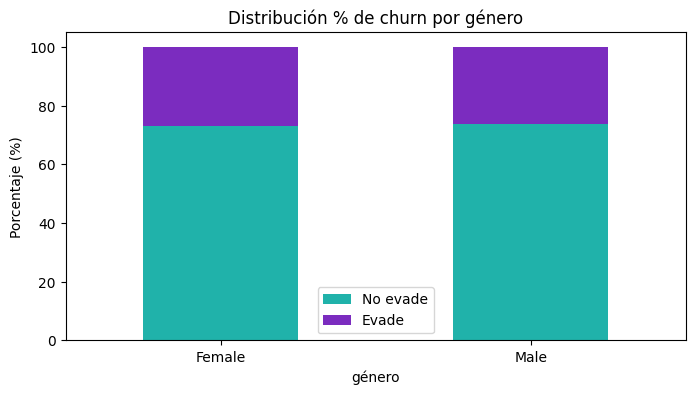


Variable: tipo_contrato


Churn,No evade,Evade
tipo_contrato,,
Anual,88.730482,11.269518
Bianual,97.168142,2.831858
Mensual,57.290323,42.709677


Churn,No evade,Evade
tipo_contrato,,
Anual,1307,166
Bianual,1647,48
Mensual,2220,1655


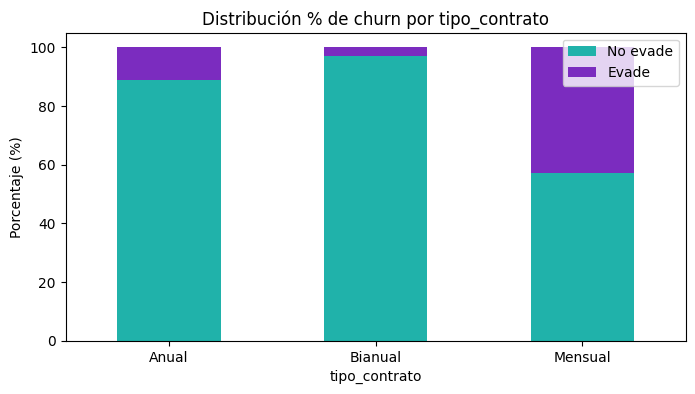


Variable: método_pago


Churn,No evade,Evade
método_pago,,
Cheque electrónico,54.714588,45.285412
Cheque enviado,80.893300,19.106700
Tarjeta automática,84.756899,15.243101
Transferencia automática,83.290155,16.709845


Churn,No evade,Evade
método_pago,,
Cheque electrónico,1294,1071
Cheque enviado,1304,308
Tarjeta automática,1290,232
Transferencia automática,1286,258


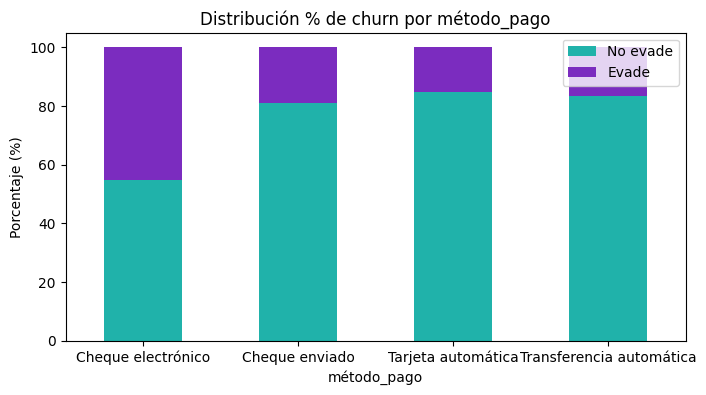


Variable: servicio_internet


Churn,No evade,Evade
servicio_internet,,
DSL,81.040892,18.959108
Fibra óptica,58.107235,41.892765
Sin servicio,92.595020,7.404980


Churn,No evade,Evade
servicio_internet,,
DSL,1962,459
Fibra óptica,1799,1297
Sin servicio,1413,113


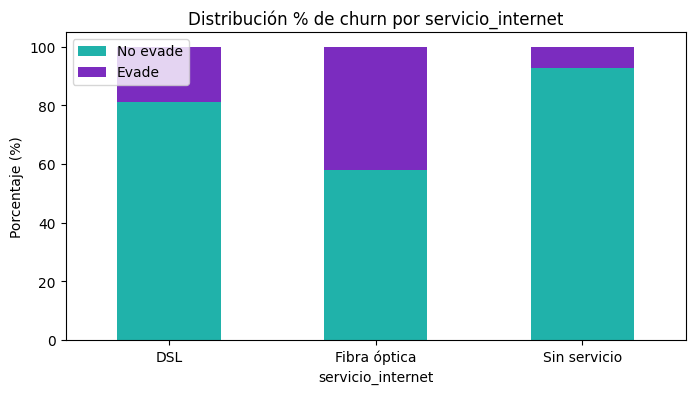

In [143]:
vars_cat = [c for c in ["género", "tipo_contrato", "método_pago", "servicio_internet"] if c in df_limpio.columns]

for col in vars_cat:
    print("\n==============================")
    print("Variable:", col)

    tabla_pct, tabla_cnt = churn_por_categoria(df_limpio, col)

    tabla_pct = tabla_pct.rename(columns={"Yes": "Evade", "No": "No evade"})
    tabla_cnt = tabla_cnt.rename(columns={"Yes": "Evade", "No": "No evade"})

    display(tabla_pct)
    display(tabla_cnt)

    tabla_pct[["No evade", "Evade"]].plot(
        kind="bar",
        stacked=True,
        figsize=(8,4),
        color=[color_fiel, color_evasion]
    )

    plt.title(f"Distribución % de churn por {col}")
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=0)
    plt.legend(title="")
    plt.show()

### **10. Conteo de evasión por variables numéricas**

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

Variables numéricas a comparar

In [144]:
vars_num = [c for c in ["antigüedad_meses", "cargo_mensual", "cargo_total", "cuentas_diarias"] if c in df_limpio.columns]

Histogramas comparativos

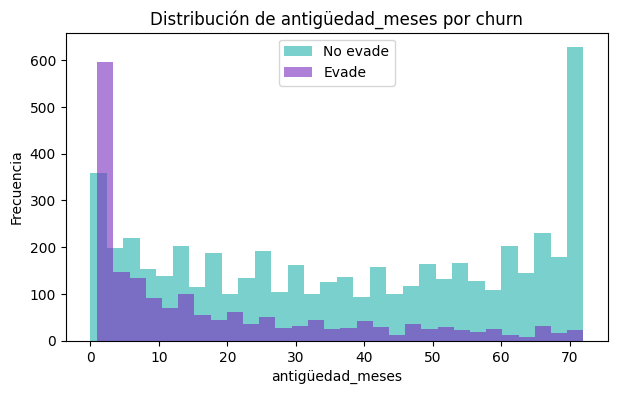

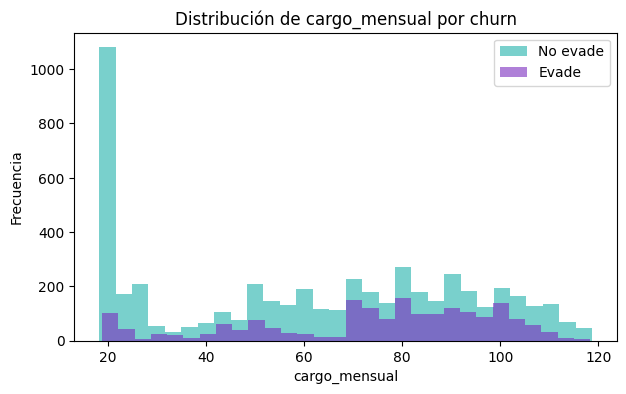

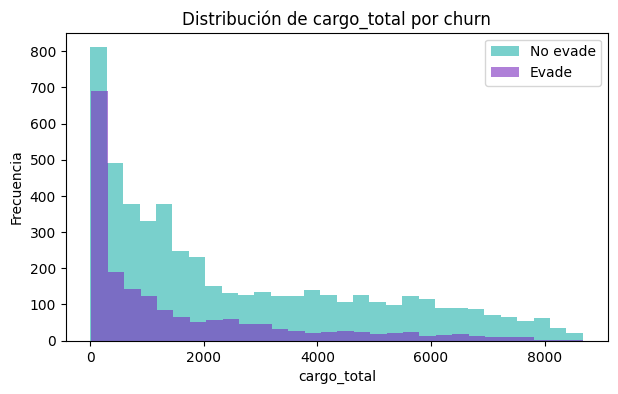

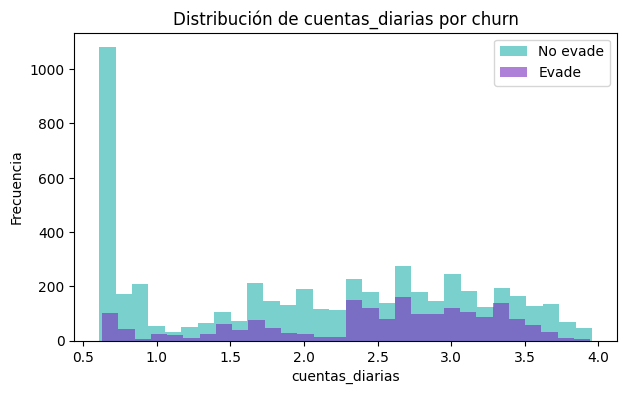

In [145]:
for col in vars_num:
    plt.figure(figsize=(7,4))

    plt.hist(
        df_limpio.loc[df_limpio["Churn"] == "No", col].dropna(),
        bins=30,
        alpha=0.6,
        label="No evade",
        color=color_fiel
    )

    plt.hist(
        df_limpio.loc[df_limpio["Churn"] == "Yes", col].dropna(),
        bins=30,
        alpha=0.6,
        label="Evade",
        color=color_evasion
    )

    plt.title(f"Distribución de {col} por churn")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

Comparación de medias

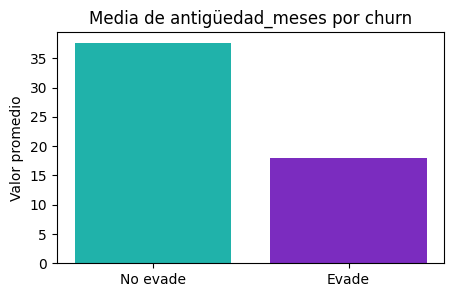

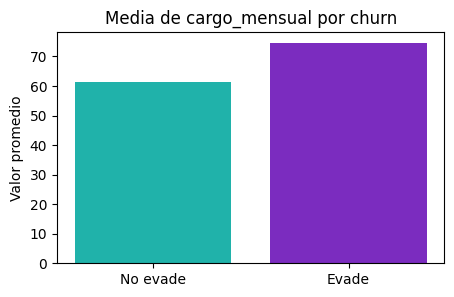

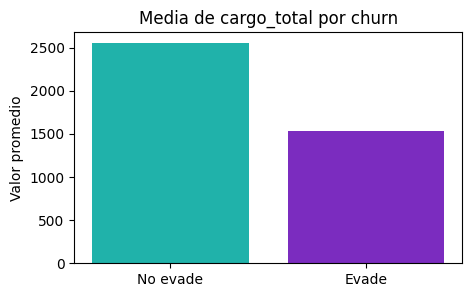

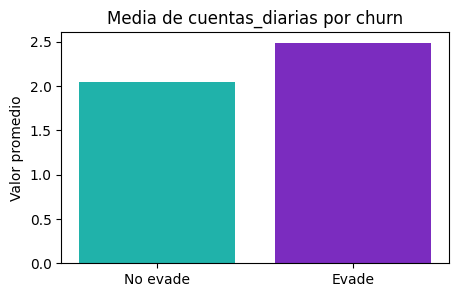

In [146]:
media_por_churn = df_limpio.groupby("Churn")[vars_num].mean().T
media_por_churn = media_por_churn.rename(columns={"No": "No evade", "Yes": "Evade"})

for col in vars_num:
    plt.figure(figsize=(5,3))

    valores = [
        media_por_churn.loc[col, "No evade"],
        media_por_churn.loc[col, "Evade"]
    ]

    plt.bar(
        ["No evade", "Evade"],
        valores,
        color=[color_fiel, color_evasion]
    )

    plt.title(f"Media de {col} por churn")
    plt.ylabel("Valor promedio")
    plt.xticks(rotation=0)
    plt.show()


Tabla resumen

In [147]:
resumen_num_por_churn = df_limpio.groupby("Churn")[vars_num].agg(["mean", "median", "std"])
display(resumen_num_por_churn)

antigüedad_meses                   cargo_mensual                     \
                  mean median        std          mean  median        std   
Churn                                                                       
No           37.569965   38.0  24.113777     61.265124  64.425  31.092648   
Yes          17.979133   10.0  19.531123     74.441332  79.650  24.666053   

       cargo_total                        cuentas_diarias                    
              mean    median          std            mean  median       std  
Churn                                                                        
No     2549.911442  1679.525  2329.954215        2.042171  2.1475  1.036422  
Yes    1531.796094   703.550  1890.822994        2.481378  2.6550  0.822202

### **11. Informe final**

Finaliza el desafío elaborando un informe dentro del mismo notebook que resuma todo el trabajo realizado. El informe debe incluir:

🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).

🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.

Asegúrate de que el informe esté bien estructurado, claro y respaldado por visualizaciones que refuercen tus conclusiones. 🚀

In [149]:

# 11.1 Introducción (contexto y objetivo)
print("INFORME FINAL — Telecom X: Análisis de churn")
print("Objetivo: comprender los factores asociados a la evasión (churn) para apoyar decisiones y futuros modelos predictivos.")
print("Dataset: clientes, datos demográficos, servicios, facturación y estado de churn.\n")


# 11.2 Resumen de limpieza y tratamiento de datos (ETL)
print("1) Limpieza y tratamiento de datos (resumen)")
print(f"- Registros totales (raw): {df_raw.shape[0]:,}")
print(f"- Registros tras filtrar churn nulo: {df_limpio.shape[0]:,}")
print(f"- Variables (post ETL): {df_limpio.shape[1]:,}")

# Nulos principales
nulos_top = df_limpio.isna().sum().sort_values(ascending=False).head(10)
print("\n- Principales nulos (top 10):")
display(nulos_top)

# Duplicados por ID
if "customerID" in df_limpio.columns:
    print("- Duplicados customerID:", int(df_limpio["customerID"].duplicated().sum()))

# Chequeos de coherencia numérica básicos
checks = {}
for col in ["cargo_total", "cargo_mensual", "antigüedad_meses", "cuentas_diarias"]:
    if col in df_limpio.columns:
        checks[f"{col}_negativos"] = int((df_limpio[col] < 0).sum())
print("- Chequeos (valores negativos):", checks)
print("\n")


# 11.3 Distribución de churn (métricas clave)
print("2) Distribución de churn")
dist = df_limpio["Churn"].value_counts()
dist_pct = df_limpio["Churn"].value_counts(normalize=True) * 100

churn_rate = float(dist_pct.get("Yes", 0))
no_churn_rate = float(dist_pct.get("No", 0))

print(f"- Tasa de churn (Yes): {churn_rate:.2f}%")
print(f"- Clientes fieles (No): {no_churn_rate:.2f}%")
display(pd.DataFrame({"conteo": dist, "porcentaje (%)": dist_pct.round(2)}))
print("\n")


# 11.4 Insights por variables categóricas (tabla resumida)
print("3) Hallazgos por variables categóricas (resumen)")

def resumen_categorica(df, col, top_n=10):
    # tabla con tasa churn y tamaño por categoría
    t = (
        df.groupby(col)["churn_bin"]
        .agg(tasa_churn="mean", n="count")
        .sort_values("tasa_churn", ascending=False)
    )
    # tasa_churn en %
    t["tasa_churn"] = (t["tasa_churn"] * 100).round(2)
    return t.head(top_n)

vars_cat = [c for c in ["género", "tipo_contrato", "método_pago", "servicio_internet"] if c in df_limpio.columns]

for col in vars_cat:
    print(f"\n- {col}: categorías con mayor tasa de churn (top)")
    display(resumen_categorica(df_limpio, col, top_n=10))


# 11.5 Insights por variables numéricas (comparación por churn)
print("\n4) Hallazgos por variables numéricas (resumen)")

vars_num = [c for c in ["antigüedad_meses", "cargo_mensual", "cargo_total", "cuentas_diarias"] if c in df_limpio.columns]
tabla_num = df_limpio.groupby("Churn")[vars_num].agg(["mean", "median", "std"])
display(tabla_num)

# diferencia de medias (Evade - No evade)
if "Yes" in df_limpio["Churn"].unique() and "No" in df_limpio["Churn"].unique():
    mean_yes = df_limpio.loc[df_limpio["Churn"] == "Yes", vars_num].mean(numeric_only=True)
    mean_no  = df_limpio.loc[df_limpio["Churn"] == "No",  vars_num].mean(numeric_only=True)
    delta = (mean_yes - mean_no).sort_values(ascending=False)
    delta = delta.round(2)
    print("\n- Diferencia de medias (Evade - No evade):")
    display(delta.to_frame("Δ media"))


# 11.6 Conclusiones e Insights (texto automático, claro y accionable)
print("\n5) Conclusiones e insights (interpretación)")
insights = []

# Insight 1: contrato (si existe)
if "tipo_contrato" in df_limpio.columns:
    t_contrato = df_limpio.groupby("tipo_contrato")["churn_bin"].mean().sort_values(ascending=False) * 100
    if len(t_contrato) >= 2:
        insights.append(
            f"- El churn varía por tipo de contrato: mayor en '{t_contrato.index[0]}' ({t_contrato.iloc[0]:.2f}%) "
            f"y menor en '{t_contrato.index[-1]}' ({t_contrato.iloc[-1]:.2f}%)."
        )

# Insight 2: método de pago (si existe)
if "método_pago" in df_limpio.columns:
    t_pago = df_limpio.groupby("método_pago")["churn_bin"].mean().sort_values(ascending=False) * 100
    if len(t_pago) >= 2:
        insights.append(
            f"- Por método de pago, la mayor tasa de churn se observa en '{t_pago.index[0]}' ({t_pago.iloc[0]:.2f}%)."
        )

# Insight 3: antigüedad (si existe)
if "antigüedad_meses" in df_limpio.columns and "Yes" in df_limpio["Churn"].unique() and "No" in df_limpio["Churn"].unique():
    avg_tenure_yes = df_limpio.loc[df_limpio["Churn"] == "Yes", "antigüedad_meses"].mean()
    avg_tenure_no  = df_limpio.loc[df_limpio["Churn"] == "No",  "antigüedad_meses"].mean()
    insights.append(
        f"- La antigüedad promedio difiere entre grupos: Evade ≈ {avg_tenure_yes:.1f} meses vs No evade ≈ {avg_tenure_no:.1f} meses."
    )

# Insight 4: cargo mensual (si existe)
if "cargo_mensual" in df_limpio.columns and "Yes" in df_limpio["Churn"].unique() and "No" in df_limpio["Churn"].unique():
    avg_m_yes = df_limpio.loc[df_limpio["Churn"] == "Yes", "cargo_mensual"].mean()
    avg_m_no  = df_limpio.loc[df_limpio["Churn"] == "No",  "cargo_mensual"].mean()
    insights.append(
        f"- El cargo mensual promedio: Evade ≈ {avg_m_yes:.2f} vs No evade ≈ {avg_m_no:.2f}."
    )

if insights:
    for s in insights:
        print(s)
else:
    print("- No se generaron insights automáticos (revisar nombres de columnas y churn_bin).")


# 11.7 Recomendaciones estratégicas (basadas en lo observado)
print("\n6) Recomendaciones (acciones sugeridas)")

recomendaciones = [
    "- Priorizar retención en segmentos con mayor tasa de churn (contratos más flexibles y métodos de pago asociados a mayor churn).",
    "- Diseñar ofertas de migración a contratos de mayor duración (beneficios por permanencia, descuentos por renovación).",
    "- Activar campañas tempranas para clientes con baja antigüedad (onboarding, seguimiento y soporte proactivo).",
    "- Revisar experiencia de facturación/pagos en los métodos con mayor churn (fricción, fallos, claridad de cobros).",
    "- En próximos pasos, construir un modelo predictivo (clasificación) usando variables transformadas + validación cruzada."
]
for r in recomendaciones:
    print(r)


# 11.8 Resumen ejecutivo en tabla (1 slide dentro del notebook)
print("\n7) Resumen ejecutivo (tabla)")
resumen_ejecutivo = pd.DataFrame({
    "Métrica": [
        "Registros analizados",
        "Variables (post ETL)",
        "Tasa churn (%)",
        "Clientes fieles (%)",
    ],
    "Valor": [
        f"{df_limpio.shape[0]:,}",
        f"{df_limpio.shape[1]:,}",
        f"{churn_rate:.2f}",
        f"{no_churn_rate:.2f}",
    ]
})
display(resumen_ejecutivo)

INFORME FINAL — Telecom X: Análisis de churn
Objetivo: comprender los factores asociados a la evasión (churn) para apoyar decisiones y futuros modelos predictivos.
Dataset: clientes, datos demográficos, servicios, facturación y estado de churn.

1) Limpieza y tratamiento de datos (resumen)
- Registros totales (raw): 7,267
- Registros tras filtrar churn nulo: 7,043
- Variables (post ETL): 24

- Principales nulos (top 10):


,0
customerID,0
Churn,0
género,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antigüedad_meses,0
servicio_telefonía,0
múltiples_líneas,0
servicio_internet,0


- Duplicados customerID: 0
- Chequeos (valores negativos): {'cargo_total_negativos': 0, 'cargo_mensual_negativos': 0, 'antigüedad_meses_negativos': 0, 'cuentas_diarias_negativos': 0}


2) Distribución de churn
- Tasa de churn (Yes): 26.54%
- Clientes fieles (No): 73.46%


,conteo,porcentaje (%)
Churn,,
No,5174,73.46
Yes,1869,26.54




3) Hallazgos por variables categóricas (resumen)

- género: categorías con mayor tasa de churn (top)


...

antigüedad_meses                   cargo_mensual                     \
                  mean median        std          mean  median        std   
Churn                                                                       
No           37.569965   38.0  24.113777     61.265124  64.425  31.092648   
Yes          17.979133   10.0  19.531123     74.441332  79.650  24.666053   

       cargo_total                        cuentas_diarias                    
              mean    median          std            mean  median       std  
Churn                                                                        
No     2549.911442  1679.525  2329.954215        2.042171  2.1475  1.036422  
Yes    1531.796094   703.550  1890.822994        2.481378  2.6550  0.822202


- Diferencia de medias (Evade - No evade):


,Δ media
cargo_mensual,13.18
cuentas_diarias,0.44
antigüedad_meses,-19.59
cargo_total,-1018.12



5) Conclusiones e insights (interpretación)
- El churn varía por tipo de contrato: mayor en 'Mensual' (42.71%) y menor en 'Bianual' (2.83%).
- Por método de pago, la mayor tasa de churn se observa en 'Cheque electrónico' (45.29%).
- La antigüedad promedio difiere entre grupos: Evade ≈ 18.0 meses vs No evade ≈ 37.6 meses.
- El cargo mensual promedio: Evade ≈ 74.44 vs No evade ≈ 61.27.

6) Recomendaciones (acciones sugeridas)
- Priorizar retención en segmentos con mayor tasa de churn (contratos más flexibles y métodos de pago asociados a mayor churn).
- Diseñar ofertas de migración a contratos de mayor duración (beneficios por permanencia, descuentos por renovación).
- Activar campañas tempranas para clientes con baja antigüedad (onboarding, seguimiento y soporte proactivo).
- Revisar experiencia de facturación/pagos en los métodos con mayor churn (fricción, fallos, claridad de cobros).
- En próximos pasos, construir un modelo predictivo (clasificación) usando variables transformadas + 

,Métrica,Valor
0,Registros analizados,"7,043"
1,Variables (post ETL),24
2,Tasa churn (%),26.54
3,Clientes fieles (%),73.46


## **¡EXTRA!**

### **12. Análisis de correlación entre variables**

Esta actividad es un extra, por lo tanto es OPCIONAL.

Como un paso adicional, puedes explorar la correlación entre diferentes variables del dataset. Esto puede ayudar a identificar qué factores tienen mayor relación con la evasión de clientes, como:

🔹 La relación entre la cuenta diaria y la evasión.
🔹 Cómo la cantidad de servicios contratados afecta la probabilidad de churn.

Puedes usar la función corr() de Pandas para calcular las correlaciones y visualizar los resultados con gráficos de dispersión o matrices de correlación.

Este análisis adicional puede proporcionar insights valiosos para la creación de modelos predictivos más robustos. 🚀

In [150]:
import seaborn as sns

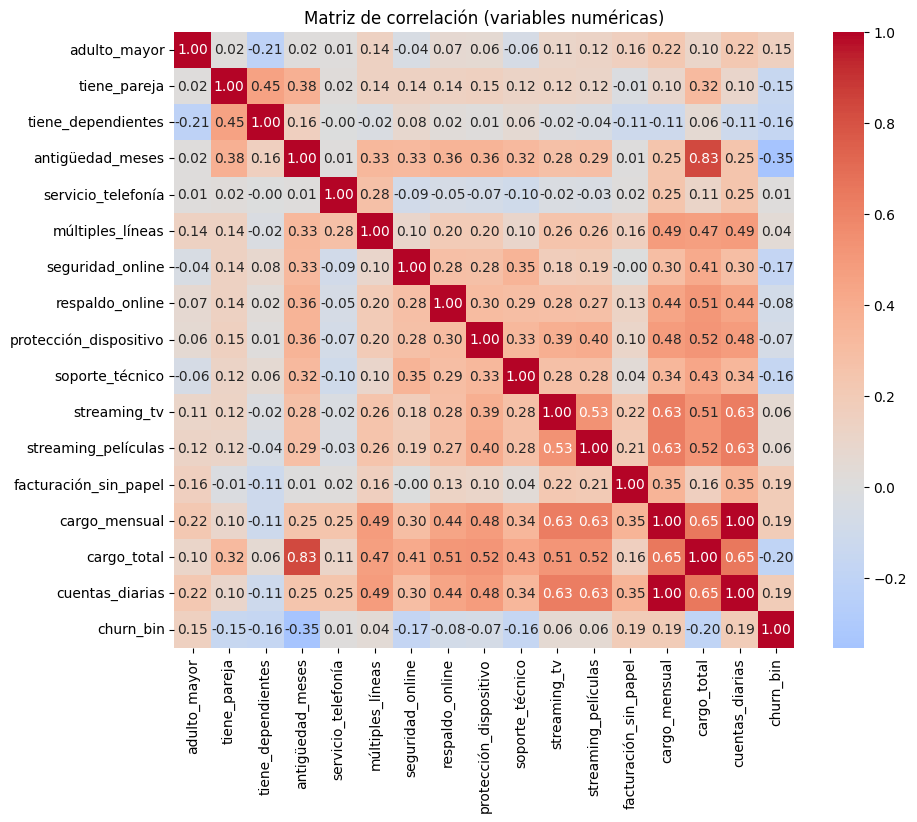

In [152]:
vars_num = df_limpio.select_dtypes(include="number").columns.tolist()

if "customerID" in vars_num:
    vars_num.remove("customerID")

corr_matrix = df_limpio[vars_num].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


Correlación específica

Correlación con churn_bin:


,churn_bin
cargo_mensual,0.193356
cuentas_diarias,0.193356
facturación_sin_papel,0.191825
adulto_mayor,0.150889
streaming_tv,0.063228
streaming_películas,0.061382
múltiples_líneas,0.040102
servicio_telefonía,0.011942
protección_dispositivo,-0.066160
respaldo_online,-0.082255


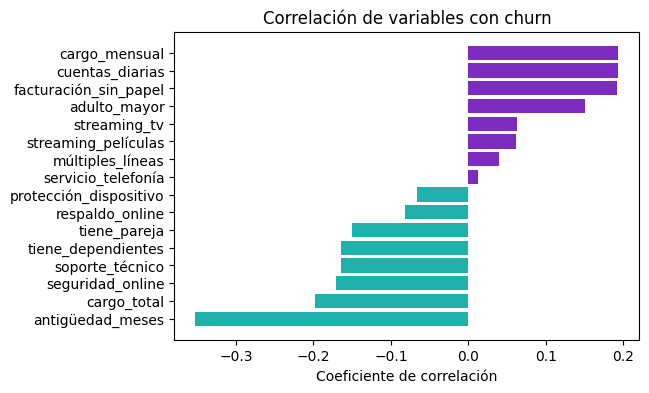

In [154]:
if "churn_bin" in df_limpio.columns:
    corr_churn = (
        corr_matrix["churn_bin"]
        .drop("churn_bin")
        .sort_values(ascending=False)
    )

    print("Correlación con churn_bin:")
    display(corr_churn)

    # Gráfico de barras ordenado
    plt.figure(figsize=(6,4))
    colors = [color_evasion if v > 0 else color_fiel for v in corr_churn.values]

    plt.barh(corr_churn.index, corr_churn.values, color=colors)
    plt.title("Correlación de variables con churn")
    plt.xlabel("Coeficiente de correlación")
    plt.gca().invert_yaxis()
    plt.show()

Relaciones visuales

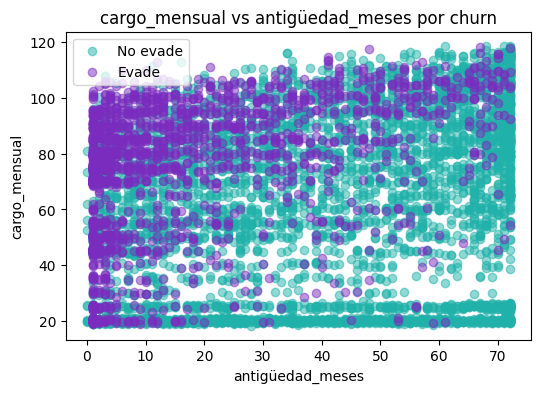

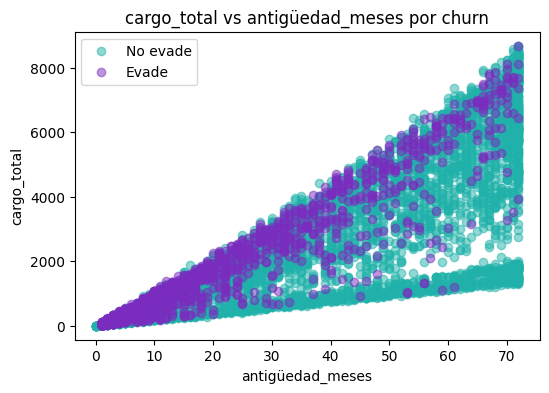

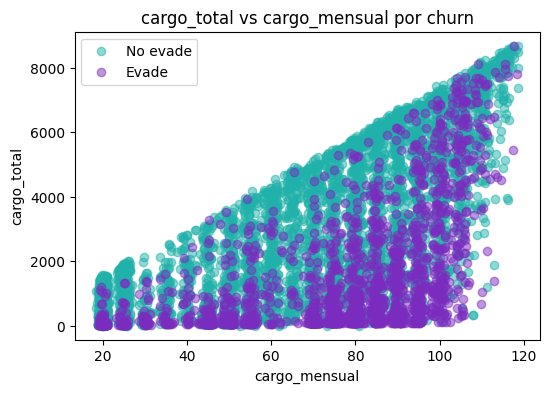

In [155]:
pares_clave = [
    ("antigüedad_meses", "cargo_mensual"),
    ("antigüedad_meses", "cargo_total"),
    ("cargo_mensual", "cargo_total")
]

for x, y in pares_clave:
    if x in df_limpio.columns and y in df_limpio.columns:
        plt.figure(figsize=(6,4))

        plt.scatter(
            df_limpio.loc[df_limpio["Churn"] == "No", x],
            df_limpio.loc[df_limpio["Churn"] == "No", y],
            alpha=0.5,
            label="No evade",
            color=color_fiel
        )

        plt.scatter(
            df_limpio.loc[df_limpio["Churn"] == "Yes", x],
            df_limpio.loc[df_limpio["Churn"] == "Yes", y],
            alpha=0.5,
            label="Evade",
            color=color_evasion
        )

        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{y} vs {x} por churn")
        plt.legend()
        plt.show()
